# Comparing all the models

All five models side by side. Reads whatever `results/preds_*_test.csv` files exist, so it works now and I just rerun it as the rest land. Nothing gets retrained.

The last part is the one that matters. Everyone scores around 0.98, so the real question is who still works on tweets with no trigger word in them.

In [1]:
!git clone -q -b part_4 https://github.com/Ebi-Tech/NLP-and-Language-Technologies.git
%cd NLP-and-Language-Technologies

/content/NLP-and-Language-Technologies


In [2]:
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, roc_auc_score

from src import metrics as M
from src.save_preds import save_preds

PROB_COLS = [f"p_{label}" for label in M.LABEL_ORDER]

## Step 1: Load the predictions

Everyone saved through `src/save_preds.py` so the columns match. I sort by `Tweet_ID` so the rows line up.

In [3]:
preds = {}
for path in sorted(glob.glob("results/preds_*_test.csv")):
    name = Path(path).stem.replace("preds_", "").replace("_test", "")
    preds[name] = pd.read_csv(path).sort_values("Tweet_ID").reset_index(drop=True)

print("found:", list(preds))
for name, d in preds.items():
    print(f"  {name}: {len(d)} rows")

found: ['distilbert']
  distilbert: 5948 rows


## Step 2: Add the majority baseline

Always predicts the biggest class. Nothing to train, so I just build it here. It's the floor: ~82% accuracy from imbalance alone.

In [4]:
if "majority" not in preds and preds:
    ref = next(iter(preds.values()))
    probs = np.zeros((len(ref), len(M.LABEL_ORDER)))
    probs[:, 4] = 1.0
    out = save_preds("majority", ref["Tweet_ID"], probs, ref["true_id"])
    preds["majority"] = pd.read_csv(out).sort_values("Tweet_ID").reset_index(drop=True)
    print("made", out)

ids = [tuple(d["Tweet_ID"]) for d in preds.values()]
truth = [tuple(d["true_id"]) for d in preds.values()]
print("same tweets in every file:", len(set(ids)) == 1)
print("same labels in every file:", len(set(truth)) == 1)

made results/preds_majority_test.csv
same tweets in every file: True
same labels in every file: True


## Step 3: The table

All computed from the predictions with the shared `compute_metrics`, so no model is scored by different code.

Read macro F1, not accuracy.

In [5]:
rows = []
for name, d in preds.items():
    m = M.compute_metrics(d["true_id"], d["pred_id"])
    row = {"model": name, "accuracy": m["accuracy"], "macro_f1": m["macro_f1"]}
    for label in M.LABEL_ORDER:
        row[f"f1_{label}"] = m["per_class_report"][label]["f1-score"]
    rows.append(row)

table = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
table.round(4)

,model,accuracy,macro_f1,f1_economic_violence,f1_emotional_violence,f1_harmful_traditional_practice,f1_physical_violence,f1_sexual_violence
0,distilbert,0.9993,0.9954,0.9841,0.9949,1.0,0.9983,0.9997
1,majority,0.8235,0.1806,0.0000,0.0000,0.0,0.0000,0.9032


## Step 4: Confusion matrices

One grid, all models. I draw my own so I don't overwrite Jean's Part 1 figures.

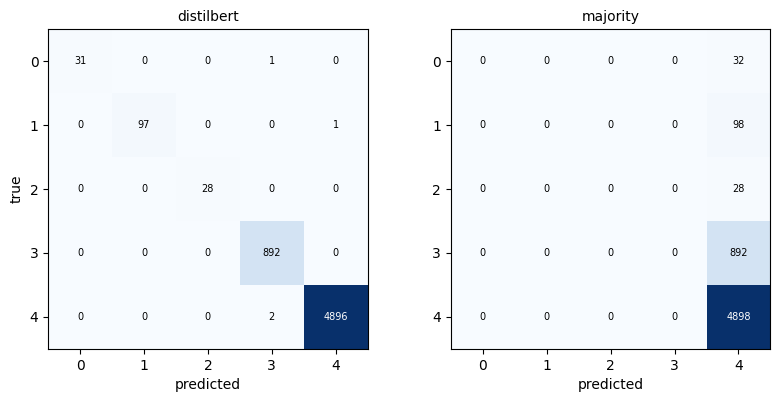

In [6]:
n = len(preds)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
axes = np.atleast_1d(axes)

for ax, (name, d) in zip(axes, preds.items()):
    cm = M.compute_metrics(d["true_id"], d["pred_id"])["confusion_matrix"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(range(5))
    ax.set_yticklabels(range(5))
    ax.set_xlabel("predicted")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() * 0.6 else "black")

axes[0].set_ylabel("true")
plt.tight_layout()
plt.savefig("reports/figures/comparison_confusion_matrices.png", dpi=150)
plt.show()

## Step 5: ROC curves

Needs the probabilities, not the labels. 5 classes so it's one against the rest, averaged into one line per model.

Averaged across classes, not tweets, otherwise `sexual_violence` drowns everything out.

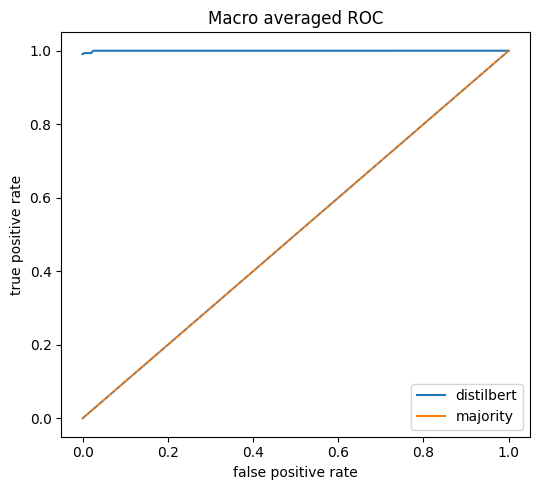

,model,auc_economic_violence,auc_emotional_violence,auc_harmful_traditional_practice,auc_physical_violence,auc_sexual_violence,macro_auc
0,distilbert,0.9993,1.0,1.0,1.0,1.0,0.9998
1,majority,0.5000,0.5,0.5,0.5,0.5,0.5000


In [7]:
grid = np.linspace(0, 1, 200)

def macro_roc(y, P):
    tprs = []
    for i in range(len(M.LABEL_ORDER)):
        fpr, tpr, _ = roc_curve((y == i).astype(int), P[:, i])
        tprs.append(np.interp(grid, fpr, tpr))
    return np.mean(tprs, axis=0)

auc_rows = []
plt.figure(figsize=(5.5, 5))

for name, d in preds.items():
    y = d["true_id"].values
    P = d[PROB_COLS].values
    plt.plot(grid, macro_roc(y, P), label=name)

    row = {"model": name}
    for i, label in enumerate(M.LABEL_ORDER):
        row[f"auc_{label}"] = roc_auc_score((y == i).astype(int), P[:, i])
    row["macro_auc"] = np.mean([row[f"auc_{l}"] for l in M.LABEL_ORDER])
    auc_rows.append(row)

plt.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Macro averaged ROC")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/comparison_roc.png", dpi=150)
plt.show()

auc = pd.DataFrame(auc_rows).sort_values("macro_auc", ascending=False).reset_index(drop=True)
auc.round(4)

## Step 6: Finding the trigger words

Refit Jean's exact pipeline just to read the top features off each class. Only to get the word list, not to report numbers.

The raw top features include words like `he` and `my`, which are in almost every tweet. Those aren't trigger words, they're just common. So I drop anything appearing in more than 10% of training tweets first, which leaves the words that actually point at one class.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

text = pd.read_csv("data/processed/train_cleaned.csv")
split = pd.read_csv("splits/train_val_test_split.csv")
merged = text.merge(split, on="Tweet_ID")
train = merged[merged["split"] == "train"]

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pipe.fit(train["tweet_clean"], train["label_id"])

TOP = 10
MAX_DF = 0.10

X = pipe["tfidf"].transform(train["tweet_clean"])
doc_freq = np.asarray((X > 0).sum(axis=0)).ravel() / X.shape[0]
too_common = doc_freq > MAX_DF
print(f"dropped {too_common.sum()} terms for appearing in over {MAX_DF:.0%} of tweets")

vocab = np.array(pipe["tfidf"].get_feature_names_out())
triggers = set()

for i, label in enumerate(M.LABEL_ORDER):
    coef = pipe["clf"].coef_[i].copy()
    coef[too_common] = -np.inf
    top = vocab[coef.argsort()[::-1][:TOP]]
    triggers.update(top)
    print(f"{label}: {', '.join(top)}")

print(f"\n{len(triggers)} trigger terms total")

economic_violence: fired, job, because, woman, was fired, fired from, was, job because, my job, because was
emotional_violence: public, humiliated, insulted, in public, in, verbally, the public, insulted me, humiliated me, he insulted
harmful_traditional_practice: forced, fgm, marriage, child marriage, undergo, genital, genital mutilation, female genital, mutilation, child
physical_violence: beats, husband, my husband, beats me, my, husband beats, he beats, beats the, beats her, wife
sexual_violence: raped, he, raped me, he raped, was raped, rape, raped and, raped by, me, raped her

50 trigger terms total


## Step 7: The hard subset

Split test into tweets with a trigger word and tweets without. The second group is the honest test.

In [9]:
pattern = re.compile(r"\b(?:" + "|".join(re.escape(t) for t in sorted(triggers)) + r")\b")

test_text = merged[merged["split"] == "test"][["Tweet_ID", "tweet_clean"]]
test_text = test_text.sort_values("Tweet_ID").reset_index(drop=True)
test_text["has_trigger"] = test_text["tweet_clean"].str.contains(pattern)

hard_ids = set(test_text.loc[~test_text["has_trigger"], "Tweet_ID"])
print(f"with a trigger word: {test_text['has_trigger'].sum()}")
print(f"without one (hard subset): {len(hard_ids)}")
print(f"hard subset is {100 * len(hard_ids) / len(test_text):.1f}% of test")
print(test_text.loc[~test_text["has_trigger"], "Tweet_ID"].map(
    merged.set_index("Tweet_ID")["label"]).value_counts())

with a trigger word: 5947
without one (hard subset): 1
hard subset is 0.0% of test


/tmp/ipykernel_1969/3947900029.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  test_text["has_trigger"] = test_text["tweet_clean"].str.contains(pattern)


In [10]:
def score(d, keep):
    sub = d[d["Tweet_ID"].isin(keep)]
    present = sorted(sub["true_id"].unique())
    return {
        "n": len(sub),
        "accuracy": (sub["true_id"] == sub["pred_id"]).mean(),
        "macro_f1": f1_score(sub["true_id"], sub["pred_id"], labels=present, average="macro", zero_division=0),
    }

easy_ids = set(test_text.loc[test_text["has_trigger"], "Tweet_ID"])

hard_rows = []
for name, d in preds.items():
    easy = score(d, easy_ids)
    hard = score(d, hard_ids)
    hard_rows.append({
        "model": name,
        "macro_f1_with_trigger": easy["macro_f1"],
        "macro_f1_no_trigger": hard["macro_f1"],
        "drop": easy["macro_f1"] - hard["macro_f1"],
        "n_hard": hard["n"],
    })

hard_table = pd.DataFrame(hard_rows).sort_values("macro_f1_no_trigger", ascending=False).reset_index(drop=True)
hard_table.round(4)

,model,macro_f1_with_trigger,macro_f1_no_trigger,drop,n_hard
0,distilbert,0.9954,1.0,-0.0046,1
1,majority,0.1806,1.0,-0.8194,1


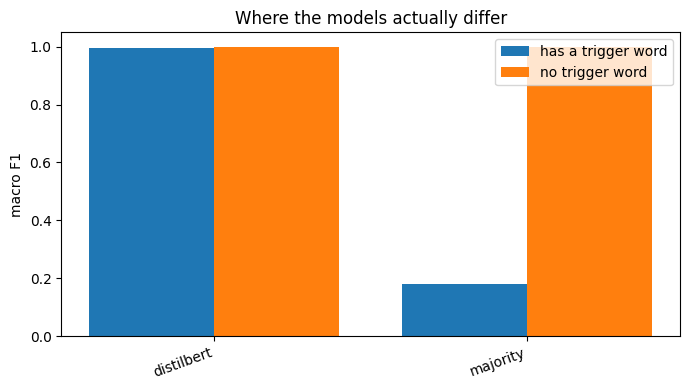

In [11]:
x = np.arange(len(hard_table))
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, hard_table["macro_f1_with_trigger"], 0.4, label="has a trigger word")
plt.bar(x + 0.2, hard_table["macro_f1_no_trigger"], 0.4, label="no trigger word")
plt.xticks(x, hard_table["model"], rotation=20, ha="right")
plt.ylabel("macro F1")
plt.title("Where the models actually differ")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/comparison_hard_subset.png", dpi=150)
plt.show()

## Step 8: What's still being missed

The tweets each model gets wrong in the hard subset, for the error analysis.

In [12]:
lookup = test_text.set_index("Tweet_ID")["tweet_clean"]

for name, d in preds.items():
    sub = d[d["Tweet_ID"].isin(hard_ids)]
    wrong = sub[sub["true_id"] != sub["pred_id"]]
    print(f"\n=== {name}: {len(wrong)} wrong out of {len(sub)} ===")
    for _, r in wrong.head(3).iterrows():
        true_label = M.LABEL_ORDER[r["true_id"]]
        pred_label = M.LABEL_ORDER[r["pred_id"]]
        print(f"  true {true_label} -> said {pred_label}")
        print(f"  {lookup[r['Tweet_ID']][:200]}")


=== distilbert: 0 wrong out of 1 ===

=== majority: 0 wrong out of 1 ===


In [13]:
table.to_csv("results/model_comparison_all.csv", index=False)
auc.to_csv("results/roc_auc_all.csv", index=False)
hard_table.to_csv("results/hard_subset_comparison.csv", index=False)
print("saved 3 tables and 3 figures")

saved 3 tables and 3 figures
